In [1]:
import numpy as np
import metaheuristic_designer as mhd
from simulator_fn import *
from fitness_fn_simple import *

In [2]:
objfunc = NeuronCircuitFit(simulation_time=100, repetitions=1)

In [ ]:
encoding = NeuronAdjMatrixSimple()
initializer = NeuronAdjMatrixSimpleInitializer(10, activation_p=0.75, encoding=encoding)
mutation = mhd.operators.OperatorVector("RandomMask", {"N": 2})
crossover = mhd.operators.OperatorVector("Multipoint")
parent_sel_op = mhd.selectionMethods.ParentSelectionNull()
survivor_sel_op = mhd.selectionMethods.SurvivorSelection("(m+n)")

search_strategy = mhd.strategies.ES(initializer, mutation, crossover, parent_sel_op, survivor_sel_op, {"offspringSize":50})
alg = mhd.algorithms.GeneralAlgorithm(
    objfunc,
    search_strategy,
    {"stop_cond": "time_limit", "time_limit": 5*60, "verbose": True, "v_timer": 0.5}
)

In [4]:
result = alg.optimize()

Initializing optimization of Fit neural circuit using ES
--------------------------------------------------------

[[  0. -13. -13.]
 [  0.   8.  13.]
 [ 13.  13.   0.]]
[[3. 4. 4.]
 [4. 1. 1.]
 [3. 3. 1.]]
0.317
[[  0. -18. -18.]
 [  8.   0.  13.]
 [  0.   8.  13.]]
[[4. 3. 4.]
 [2. 3. 3.]
 [1. 3. 2.]]
0.2285
[[  0. -18. -13.]
 [  0.  13.   0.]
 [ 13.   0.   8.]]
[[1. 2. 1.]
 [1. 4. 5.]
 [2. 4. 3.]]
0.111
[[  0. -13. -18.]
 [  8.   0.   8.]
 [ 13.  13.  13.]]
[[1. 3. 4.]
 [3. 4. 3.]
 [5. 1. 1.]]
0.37450000000000006
[[-18.  -8.   0.]
 [  8.   0.   8.]
 [  8.  13.   0.]]
[[1. 3. 5.]
 [4. 2. 4.]
 [1. 2. 5.]]
0.10250000000000001
[[-8. -8. -8.]
 [ 8. 13. 13.]
 [13.  8.  8.]]
[[5. 4. 5.]
 [5. 1. 4.]
 [1. 1. 5.]]
0.552
[[-18.   0. -13.]
 [  0.   0.   8.]
 [  8.  13.  13.]]
[[5. 4. 2.]
 [3. 2. 3.]
 [3. 1. 1.]]
0.583
[[-13.  -8. -18.]
 [ 13.   0.   0.]
 [  0.   8.   0.]]
[[2. 4. 2.]
 [2. 1. 3.]
 [3. 4. 5.]]
0.314
[[-18.   0.   0.]
 [ 13.  13.   8.]
 [  0.   8.   8.]]
[[5. 1. 2.]
 [3. 5. 5.]
 [

In [5]:
best_solution, best_fit = result.best_solution(decoded=True)
best_solution, best_fit

(array([[[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0., -13.,   0.,  -8.],
         [  0.,   0.,   0.,   0.,   0.,  13.,  13.,   8.],
         [  0.,   0.,   0.,   0.,   0.,   0.,  13.,  13.]],
 
        [[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
         [  0.,   0.,   0.,   0.,   0.,   2.,   4.,   2.],
         [  0.,   0.,   0.,   0.,   0.,   2.,   1.,   1.],
         [  0.,   0.,   0.,   0.,   0.,   3.,   5.,   5.]]]),
 np.float64(2.500000000000282e-07))

In [6]:
sim, volt = run_simulator(best_solution[0], best_solution[1], record_volt=True)

In [10]:
n_idx = 0

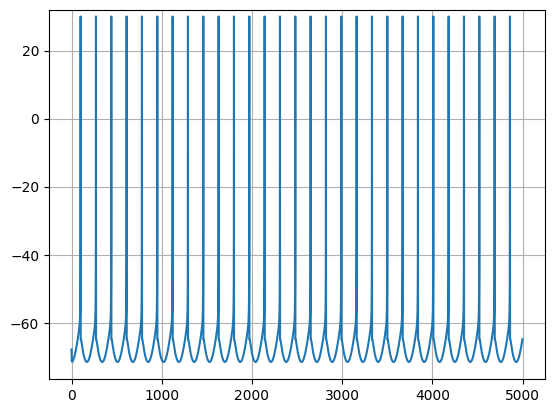

In [71]:
# plt.stem(volt[15, :1000], bottom=-80)
plt.plot(volt[n_idx, :5000])
plt.ylim((None, 32))
plt.grid()
plt.show()
n_idx += 1
n_idx = n_idx % len(volt)

In [9]:
np.diff(sim[12])

array([0.005, 0.004, 0.005, ..., 0.005, 0.004, 0.005])